# CRN Boltzmann Equilibrium — Parameter Sweep

Loads `boltzmann_scan.csv` (generated by `boltzmann_scan.py`) and visualises
the thermodynamic **correct-dimer fraction** as contour plots in 2D parameter
slices.

**Run first:**
```bash
python boltzmann_scan.py
```

**Metrics:**
- `correct_fraction` = 2·Σ(correct dimer concentrations) / total monomer content  
  Equals 1 when all monomers are in correct dimers; matches the training score.
- `selectivity` = Σcorrect / (Σcorrect + Σincorrect)  
  Fraction of *formed dimers* that are correct; independent of overall extent of dimerisation.

**Default fixed values** (used when a parameter is not on an axis): `phi=0.1, J≈2.39 (nearest grid value to 2.5), n_species=4, n_types=1, pH=7.0`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

plt.rcParams.update({'figure.dpi': 130, 'font.size': 10})

df = pd.read_csv('boltzmann_scan.csv')
print(f"Loaded {len(df):,} rows, {len(df.columns)} columns")
print("\nParameter values in scan:")
for col in ['phi', 'J', 'n_species', 'n_types', 'pH']:
    vals = sorted(df[col].unique())
    print(f"  {col:12s}: {vals}")

/Users/samwhitby/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/samwhitby/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


Loaded 31,500 rows, 14 columns

Parameter values in scan:
  phi         : [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0]
  J           : [0.5, 0.7368, 0.9737, 1.2105, 1.4474, 1.6842, 1.9211, 2.1579, 2.3947, 2.6316, 2.8684, 3.1053, 3.3421, 3.5789, 3.8158, 4.0526, 4.2895, 4.5263, 4.7632, 5.0]
  n_species   : [2, 4, 6, 8, 10]
  n_types     : [1, 2, 3, 4, 5]
  pH          : [5.0, 7.0, 9.0]


In [ ]:
def _nearest(series, val):
    """Return the value in series.unique() closest to val."""
    arr = np.array(sorted(series.unique()))
    return arr[np.argmin(np.abs(arr - val))]

# Default parameter values for slices
# J is snapped to the nearest grid value (2.5 is not in the scan grid)
DEFAULTS = dict(phi=0.1, J=_nearest(df['J'], 2.5), n_species=4, n_types=1, pH=7.0)

def plot_contour(df, x_param, y_param, z_col='correct_fraction',
                 fixed=None, ax=None, cmap='viridis', n_levels=14,
                 vmin=0.0, vmax=1.0, show_cbar=True, title=None):
    """
    2D contour of z_col(x_param, y_param) with all other params fixed.

    Parameters
    ----------
    fixed : dict  override default fixed values for non-axis parameters
    """
    if fixed is None:
        fixed = {k: v for k, v in DEFAULTS.items()
                 if k not in (x_param, y_param)}
    mask = np.ones(len(df), dtype=bool)
    for k, v in fixed.items():
        if k in df.columns:
            mask &= np.isclose(df[k].values, v, atol=1e-6)
    sub = df[mask]
    if len(sub) == 0:
        print(f"  No rows for fixed={fixed}")
        return None
    pivot = sub.pivot_table(
        index=y_param, columns=x_param, values=z_col, aggfunc='mean')
    X = pivot.columns.values.astype(float)
    Y = pivot.index.values.astype(float)
    Z = pivot.values

    own_fig = (ax is None)
    if own_fig:
        _, ax = plt.subplots(figsize=(6, 4.5))

    levels = np.linspace(vmin, vmax, n_levels + 1)
    cf = ax.contourf(X, Y, Z, levels=levels, cmap=cmap, vmin=vmin, vmax=vmax,
                     extend='both')
    cs = ax.contour(X, Y, Z, levels=np.arange(0.1, 1.0, 0.1),
                    colors='white', linewidths=0.7, alpha=0.55)
    ax.clabel(cs, fmt='%.1f', fontsize=6.5, colors='white')
    ax.set_xlabel(x_param, fontsize=11)
    ax.set_ylabel(y_param, fontsize=11)
    display_fixed = {k: v for k, v in fixed.items()
                     if k in ('phi', 'J', 'n_species', 'n_types', 'pH')}
    fixed_str = ', '.join(f'{k}={v}' for k, v in display_fixed.items())
    ax.set_title(title or f'[{fixed_str}]', fontsize=8.5)
    if show_cbar and own_fig:
        plt.colorbar(cf, ax=ax, label=z_col.replace('_', ' '))
    if own_fig:
        plt.tight_layout()
        plt.show()
    return cf


---
## 1. J vs φ — the fundamental selectivity trade-off

**Physical picture.** Each correct bond (acid–base *same* species pair) has
free energy $\Delta G_\text{correct} = J \cdot q_i q_j < 0$ (attractive).
Wrong acid–base pairs (e.g. A paired with D instead of B) have
$\Delta G_\text{wrong} = \phi J \cdot q_i q_j < 0$ as well — they are
also attractive, but weakened by $\phi$.  Same-sign pairs (A–A, B–B, etc.)
are *repulsive* and naturally suppressed regardless of $\phi$.

The key dimensionless driver of selectivity is therefore
$$\Delta\Delta G = J(1-\phi)\,q^2 \approx J(1-\phi)\times 0.83 \quad [\text{kT at pH 7}]$$
which is the free-energy *difference* between the correct and the best
competing wrong bond.  Selectivity is good when $J(1-\phi) \gtrsim 1.2\,\text{kT}$.

**Expected shape.** Iso-fraction contours should roughly follow the hyperbola
$J = c\,/\,(1-\phi)$, becoming steeper as $\phi \to 1$ (any amount of J is
insufficient when $\phi=1$) and flattening at low $\phi$ (even modest J suffices).

**pH dependence.** The magnitude of $q$ depends on how far the pH is from the
pKa values.  At pH 7 with pKa\_acid=6, pKa\_base=8 the charges are near their
maximum ($|q|\approx 0.91$), giving strong driving force.  At pH values close
to the pKa the charges are reduced and a higher J is needed to achieve the
same fraction.

In [ ]:
# J vs phi at three pH values — correct_fraction
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
pH_vals = [5.0, 7.0, 9.0]
base_fixed = {k: v for k, v in DEFAULTS.items() if k not in ('J', 'phi', 'pH')}

def _transition_J(df_slice, phi_col='phi', J_col='J',
                   z_col='correct_fraction', target=0.5):
    """Interpolated J at which correct_fraction crosses target, per phi."""
    phi_pts, J_pts = [], []
    for phi_val in sorted(df_slice[phi_col].unique()):
        row = df_slice[np.isclose(df_slice[phi_col], phi_val)].sort_values(J_col)
        above = row[row[z_col] >= target]
        if len(above) == 0:
            continue
        j_above = above[J_col].min()
        below = row[(row[z_col] < target) & (row[J_col] < j_above)]
        if len(below) > 0:
            j_below = below[J_col].max()
            f_below = float(below.loc[below[J_col].idxmax(), z_col])
            f_above = float(above.loc[above[J_col].idxmin(), z_col])
            t = (target - f_below) / (f_above - f_below + 1e-15)
            j_interp = j_below + t * (j_above - j_below)
        else:
            j_interp = j_above
        phi_pts.append(phi_val)
        J_pts.append(j_interp)
    return np.array(phi_pts), np.array(J_pts)

for ax, ph in zip(axes, pH_vals):
    cf = plot_contour(df, 'J', 'phi',
                      fixed={**base_fixed, 'pH': ph},
                      ax=ax, show_cbar=False,
                      title=f'pH = {ph}')
    # Overlay the empirical correct_fraction = 0.5 transition
    mask = np.ones(len(df), dtype=bool)
    for k, v in {**base_fixed, 'pH': ph}.items():
        if k in df.columns:
            mask &= np.isclose(df[k].values, v, atol=1e-6)
    phi_t, J_t = _transition_J(df[mask])
    ax.plot(J_t, phi_t, 'r--', linewidth=1.4,
            label='correct fraction = 0.5')
    ax.set_xlim(df['J'].min(), df['J'].max())
    ax.set_ylim(0, 1)
    if ph == pH_vals[0]:
        ax.legend(fontsize=8)
if cf is not None:
    cbar = fig.colorbar(cf, ax=axes, shrink=0.85, pad=0.02)
    cbar.set_label('correct fraction', fontsize=11)
fig.suptitle('Correct-dimer fraction: φ vs J  (n_species=4, n_types=1)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('boltzmann_J_phi.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved boltzmann_J_phi.png')


/var/folders/7m/x2l109cj33l8xldkm_3fd6hm0000gn/T/ipykernel_69240/2957630119.py:13: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


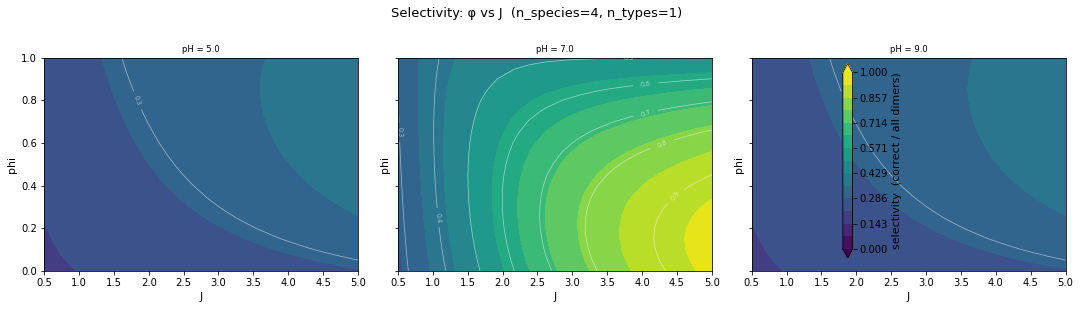

In [4]:
# Same axes but showing selectivity instead of correct_fraction
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
for ax, ph in zip(axes, pH_vals):
    cf = plot_contour(df, 'J', 'phi', z_col='selectivity',
                      fixed={**base_fixed, 'pH': ph},
                      ax=ax, show_cbar=False,
                      title=f'pH = {ph}')
if cf is not None:
    cbar = fig.colorbar(cf, ax=axes, shrink=0.85, pad=0.02)
    cbar.set_label('selectivity  (correct / all dimers)', fontsize=11)
fig.suptitle('Selectivity: φ vs J  (n_species=4, n_types=1)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('boltzmann_J_phi_selectivity.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 2. Effect of system complexity — n\_species

**Physical picture.** Increasing `n_species` adds more monomer types to the
solution, all at the same total concentration (M=1 is fixed, so each individual
monomer's initial concentration is 1/N).  Two competing effects operate:

1. **More wrong acid–base pairs**: for n_species=4 there are 2 wrong acid–base
   cross-pairs; for n_species=8 there are 8 such pairs. Each has
   $\Delta G = \phi J q^2 < 0$, so they actively compete with correct bonds.
2. **Concentration dilution**: more species → lower $C_i = 1/N$ →
   dimer formation rate $\propto C_i C_j \propto 1/N^2$ → fewer dimers overall.
   This quadratic dilution initially *suppresses* incorrect dimers more than
   correct ones (since correct dimers are always more stable per encounter).

**Expected shape.** At small n_species (2–4), a modest J is sufficient for
good folding.  As n_species grows the iso-fraction contours shift to higher J:
you need a stronger coupling to overcome the increased competition.  The shift
is logarithmic in the number of competing pairs, so the required extra J per
doubling of species is roughly $\sim \ln(n_\text{competing})/q^2$.

At $\phi=0$ the competing acid–base cross pairs have $K=1$ (ΔG=0), so even
at large n_species the correct dimers dominate at high J — the correct fraction
saturates rather than collapsing.  At large $\phi$ the cross pairs become as
attractive as correct ones and the correct fraction falls sharply.

/var/folders/7m/x2l109cj33l8xldkm_3fd6hm0000gn/T/ipykernel_69240/3644482809.py:16: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


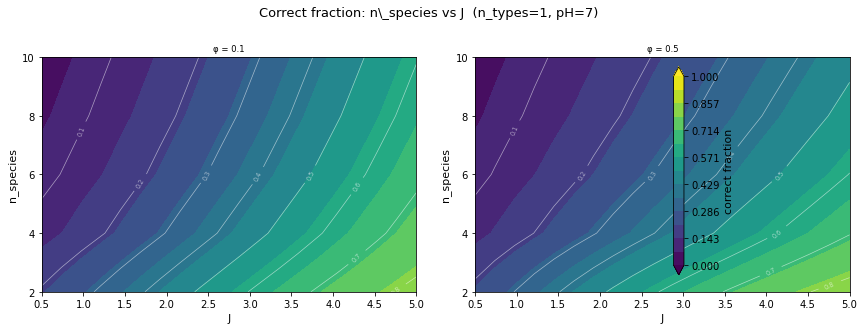

In [5]:
# J vs n_species at two phi values, correct_fraction
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, phi_val in zip(axes, [0.1, 0.5]):
    fixed = {k: v for k, v in DEFAULTS.items()
             if k not in ('J', 'n_species', 'phi')}
    fixed['phi'] = phi_val
    cf = plot_contour(df, 'J', 'n_species', fixed=fixed,
                      ax=ax, show_cbar=False,
                      title=f'φ = {phi_val}')
    ax.set_yticks(sorted(df['n_species'].unique()))
if cf is not None:
    cbar = fig.colorbar(cf, ax=axes, shrink=0.85, pad=0.02)
    cbar.set_label('correct fraction', fontsize=11)
fig.suptitle('Correct fraction: n\_species vs J  (n_types=1, pH=7)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('boltzmann_J_nspecies.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Effect of n\_types (degeneracy)

**Physical picture.** With `n_types=T`, each species has T identical copies
(A1, A2, ..., A_T).  Correct bonds are *same-type* pairs only: (A1–B1), (A2–B2),
etc.  Additional bonds introduced by T>1:

- **Wrong-type same-species-pair bonds** (A1–B2, A2–B1, etc.):
  $\Delta G = \phi J q^2 < 0$ — attractive at high $\phi$.
  For the system to tell A1–B1 from A1–B2 it must rely entirely on $\phi$
  (since J is the same for both).
- **Same-species cross-type bonds** (A1–A2, B1–B2): repulsive regardless of
  $\phi$ because they carry the same-sign charge.
- **Concentration dilution**: N = n_species × T increases with T, reducing
  each monomer's concentration $1/N$, which quadratically reduces all dimer
  fractions.

**Expected shape.** At $\phi \approx 0$ (perfect specificity) the wrong-type
same-pair bonds have $\Delta G \approx 0$, so they contribute as many K=1
background dimers as any random collision.  The correct_fraction at fixed J
will *decrease* with T purely from dilution.  At high $\phi$ the wrong-type
bonds become strongly attractive, amplifying competition and driving the
correct fraction even lower.  The n_types contours should therefore shift
monotonically downward as T increases, with the sharpest effect at high $\phi$.

**Key implication**: adding types (degeneracy) is *never beneficial* for
thermodynamic selectivity; it either dilutes the signal (low $\phi$) or
introduces competing wrong-type pairs (high $\phi$).  In a real polymer the
analogue is having multiple residues of the same chemical identity — a design
challenge for specificity.

/var/folders/7m/x2l109cj33l8xldkm_3fd6hm0000gn/T/ipykernel_69240/2634336932.py:16: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


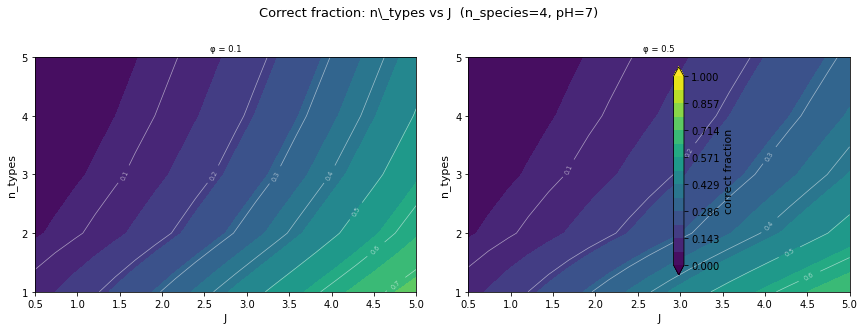

In [6]:
# J vs n_types at two phi values
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, phi_val in zip(axes, [0.1, 0.5]):
    fixed = {k: v for k, v in DEFAULTS.items()
             if k not in ('J', 'n_types', 'phi')}
    fixed['phi'] = phi_val
    cf = plot_contour(df, 'J', 'n_types', fixed=fixed,
                      ax=ax, show_cbar=False,
                      title=f'φ = {phi_val}')
    ax.set_yticks(sorted(df['n_types'].unique()))
if cf is not None:
    cbar = fig.colorbar(cf, ax=axes, shrink=0.85, pad=0.02)
    cbar.set_label('correct fraction', fontsize=11)
fig.suptitle('Correct fraction: n\_types vs J  (n_species=4, pH=7)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('boltzmann_J_ntypes.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. n\_species vs n\_types — degeneracy vs diversity

**Physical picture.** This plot separates two orthogonal routes to increasing
the total particle count N = n\_species × n\_types:

- **More species** (x-axis): adds new chemical identities, each with its own
  pKa.  At low $\phi$ the competing wrong acid–base bonds are neutral;
  selectivity is primarily determined by how many correct bonds can outcompete
  many neutral ones.  At $\phi>0$ the wrong cross-species bonds become
  attractive competitors.
- **More types** (y-axis): adds degenerate copies of existing species.  Correct
  fraction can only degrade because (a) concentration dilution and (b) wrong-type
  same-pair bonds become competitive at $\phi>0$.

**Expected shape.** The correct fraction should decrease monotonically along
both axes (both routes increase competition or dilution).  The two axes are
qualitatively different: moving right (more species) is more damaging at large
$\phi$; moving up (more types) is roughly equivalent damage per unit N increase
across all $\phi$ values because the wrong-type bonds are a constant fraction
of competitors regardless of how many species exist.

  No rows for fixed={'J': 2.5, 'pH': 7.0, 'phi': 0.1}
  No rows for fixed={'J': 2.5, 'pH': 7.0, 'phi': 0.5}


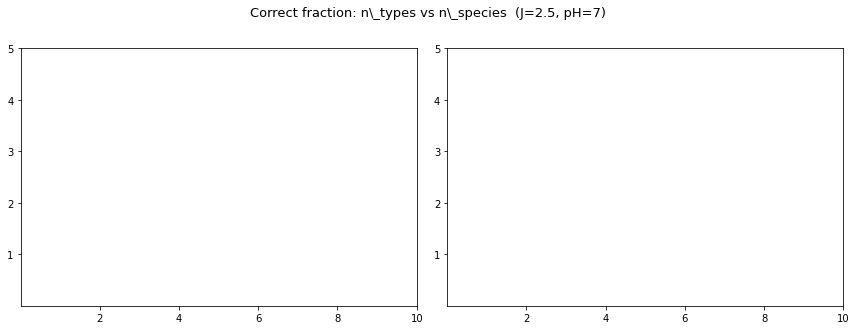

In [8]:
# n_species vs n_types at two phi values
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, phi_val in zip(axes, [0.1, 0.5]):
    fixed = {k: v for k, v in DEFAULTS.items()
             if k not in ('n_species', 'n_types', 'phi')}
    fixed['phi'] = phi_val
    cf = plot_contour(df, 'n_species', 'n_types', fixed=fixed,
                      ax=ax, show_cbar=False,
                      title=f'φ = {phi_val}')
    ax.set_xticks(sorted(df['n_species'].unique()))
    ax.set_yticks(sorted(df['n_types'].unique()))
if cf is not None:
    cbar = fig.colorbar(cf, ax=axes, shrink=0.85, pad=0.02)
    cbar.set_label('correct fraction', fontsize=11)
fig.suptitle('Correct fraction: n\_types vs n\_species  (J≈2.39, pH=7)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('boltzmann_nspecies_ntypes.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Overview: all six pairwise combinations

The 2×3 grid below shows every combination of the four trainable parameters
{J, φ, n\_species, n\_types} as a 2D contour slice.  All other parameters
are fixed at the defaults (pH=7, plus whichever of the four are not on the
axes).  This gives a global picture of the parameter landscape and makes it
easy to identify which dimensions matter most for achieving a high correct
fraction.

**Interpretation guide:**
- Steep iso-lines → the parameter on that axis is critical; small changes have large effects.
- Flat iso-lines → the parameter on that axis is unimportant for this slice.
- The upper-right quadrant should generally be good (high J = strong coupling,
  low n_species / n_types = simpler system).
- The J–φ panel gives the *intrinsic limit* of the CRN chemistry; all other
  panels show how system complexity erodes that limit.

  No rows for fixed={'J': 2.5, 'n_types': 1, 'pH': 7.0}
  No rows for fixed={'J': 2.5, 'n_species': 4, 'pH': 7.0}
  No rows for fixed={'phi': 0.1, 'J': 2.5, 'pH': 7.0}


/var/folders/7m/x2l109cj33l8xldkm_3fd6hm0000gn/T/ipykernel_69240/682301065.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


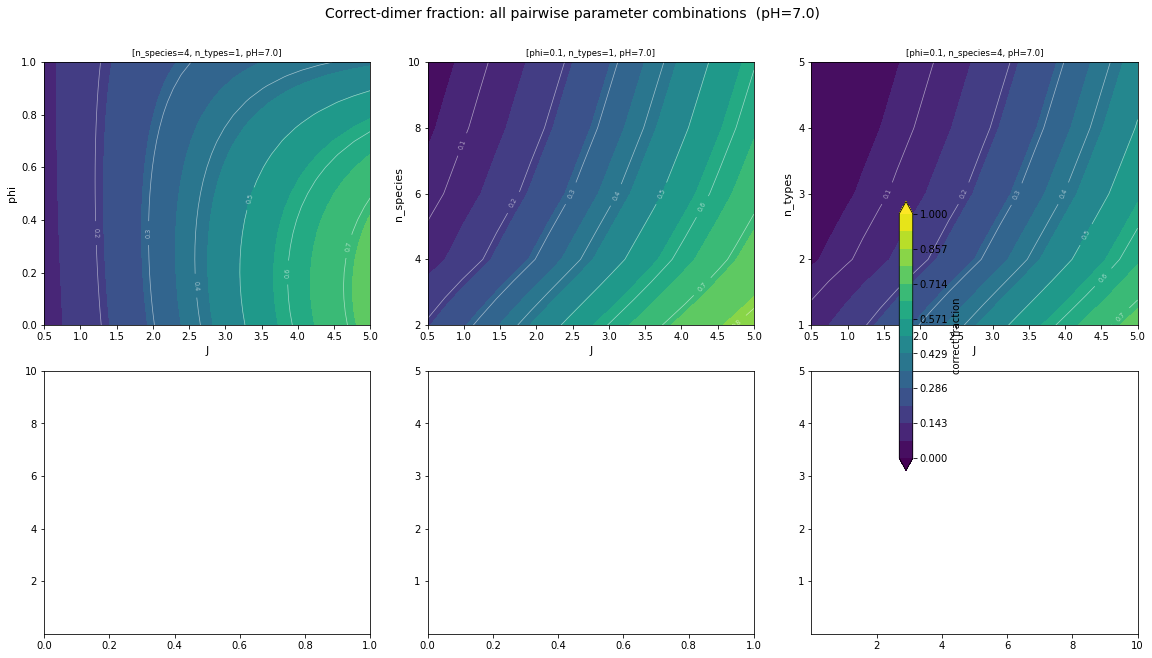

Saved boltzmann_overview.png


In [9]:
pairs = [
    ('J', 'phi'),
    ('J', 'n_species'),
    ('J', 'n_types'),
    ('phi', 'n_species'),
    ('phi', 'n_types'),
    ('n_species', 'n_types'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes_flat = axes.flatten()

last_cf = None
for ax, (xp, yp) in zip(axes_flat, pairs):
    fixed = {k: v for k, v in DEFAULTS.items() if k not in (xp, yp)}
    cf = plot_contour(df, xp, yp, fixed=fixed, ax=ax, show_cbar=False)
    if cf is not None:
        last_cf = cf
    # Mark integer ticks for discrete parameters
    if xp in ('n_species', 'n_types'):
        ax.set_xticks(sorted(df[xp].unique()))
    if yp in ('n_species', 'n_types'):
        ax.set_yticks(sorted(df[yp].unique()))

if last_cf is not None:
    fig.colorbar(last_cf, ax=axes_flat, shrink=0.55, pad=0.02,
                 label='correct fraction')
fig.suptitle(
    'Correct-dimer fraction: all pairwise parameter combinations  (pH=7.0)',
    fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('boltzmann_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved boltzmann_overview.png")

---
## 6. Minimum J required to exceed a target correct fraction

A practical question for designing a CRN: *given my system parameters, what
J do I need to guarantee correct\_fraction ≥ 0.5?*

The cell below extracts the threshold J from the CSV and plots it as a
function of (φ, n_species) and (φ, n_types), giving a design-space map.

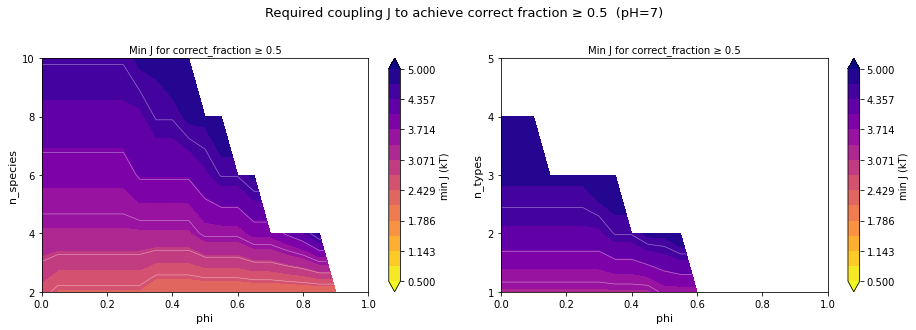

Saved boltzmann_min_J.png


In [10]:
TARGET_FRACTION = 0.5   # adjust as desired

def min_J_for_target(df, row_param, col_param, target=TARGET_FRACTION,
                     fixed=None):
    """For each (row_param, col_param) combination, find the smallest J
    at which correct_fraction >= target."""
    if fixed is None:
        fixed = {k: v for k, v in DEFAULTS.items()
                 if k not in (row_param, col_param, 'J')}
    mask = np.ones(len(df), dtype=bool)
    for k, v in fixed.items():
        if k in df.columns:
            mask &= np.isclose(df[k].values, v, atol=1e-6)
    sub = df[mask]
    rows = []
    for rval in sorted(sub[row_param].unique()):
        for cval in sorted(sub[col_param].unique()):
            cell = sub[(np.isclose(sub[row_param], rval, atol=1e-6)) &
                       (np.isclose(sub[col_param], cval, atol=1e-6))].sort_values('J')
            above = cell[cell['correct_fraction'] >= target]
            j_min = above['J'].min() if len(above) > 0 else np.nan
            rows.append({row_param: rval, col_param: cval, 'J_min': j_min})
    return pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, (rp, cp) in zip(axes, [('n_species', 'phi'), ('n_types', 'phi')]):
    res = min_J_for_target(df, rp, cp)
    piv = res.pivot(index=rp, columns=cp, values='J_min')
    X = piv.columns.values.astype(float)
    Y = piv.index.values.astype(float)
    Z = piv.values
    cf = ax.contourf(X, Y, Z, levels=np.linspace(0.5, 5.0, 15),
                     cmap='plasma_r', vmin=0.5, vmax=5.0, extend='both')
    ax.contour(X, Y, Z, levels=np.linspace(0.5, 5.0, 10),
               colors='white', linewidths=0.6, alpha=0.5)
    fig.colorbar(cf, ax=ax, label='min J (kT)')
    ax.set_xlabel('phi', fontsize=11)
    ax.set_ylabel(rp, fontsize=11)
    ax.set_title(f'Min J for correct_fraction ≥ {TARGET_FRACTION}', fontsize=10)
    ax.set_yticks(sorted(res[rp].unique()))

fig.suptitle(f'Required coupling J to achieve correct fraction ≥ {TARGET_FRACTION}  (pH=7)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('boltzmann_min_J.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved boltzmann_min_J.png")